In [19]:
%matplotlib notebook

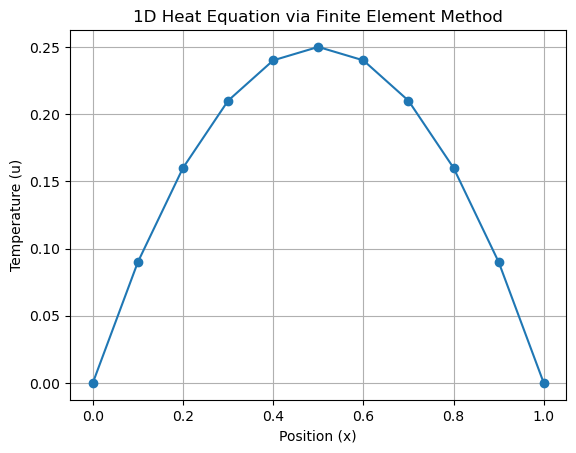

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup Parameters
L = 1.0           # Length of the rod
n_elements = 10   # Number of finite elements
n_nodes = n_elements + 1
h = L / n_elements  # Size of each element
f_value = 2.0     # Constant heat source term

# 2. Initialize Global Stiffness Matrix (K) and Load Vector (F)
K = np.zeros((n_nodes, n_nodes))
F = np.zeros(n_nodes)

# 3. Assembly Process (The "Heart" of FEA)
# We loop through each element and "stamp" its local stiffness into the global K
for i in range(n_elements):
    # Local stiffness for 1D Poisson: (1/h) * [[1, -1], [-1, 1]]
    K[i:i+2, i:i+2] += (1/h) * np.array([[1, -1], [-1, 1]])
    
    # Local load vector: (f*h/2) * [1, 1]
    F[i:i+2] += (f_value * h / 2) * np.array([1, 1])

# 4. Apply Boundary Conditions (u(0) = 0 and u(1) = 0)
# We "shrink" the system to solve only for internal nodes
K_internal = K[1:-1, 1:-1]
F_internal = F[1:-1]

# 5. Solve the Linear System (Ku = F)
u_internal = np.linalg.solve(K_internal, F_internal)

# Reconstruct full solution vector with boundary zeros
u = np.concatenate(([0], u_internal, [0]))
x = np.linspace(0, L, n_nodes)

# 6. Plotting
plt.plot(x, u, 'o-', label='FEA Solution')
plt.title("1D Heat Equation via Finite Element Method")
plt.xlabel("Position (x)")
plt.ylabel("Temperature (u)")
plt.grid(True)
plt.show()

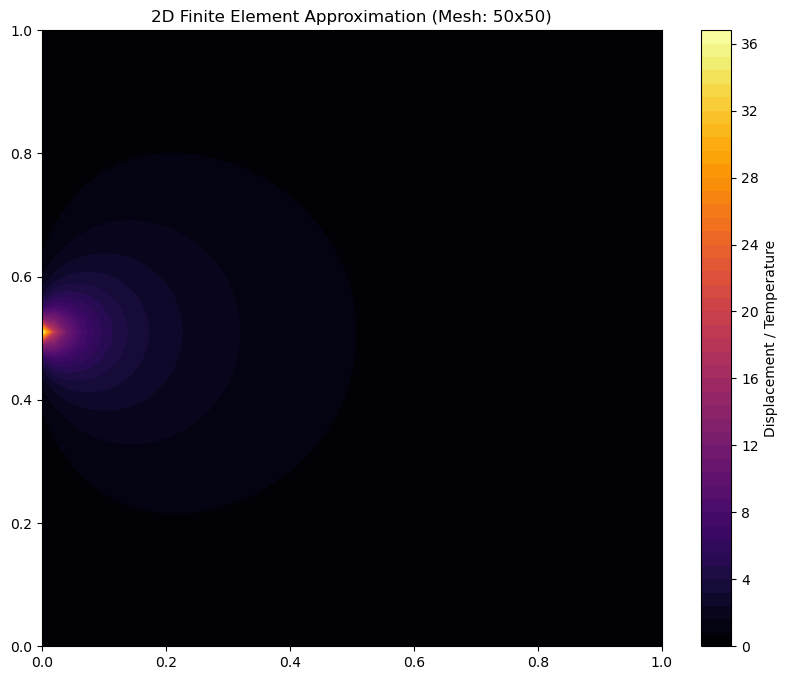

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import linalg, csr_matrix

# 1. Mesh Parameters
N = 50  # Number of points in each direction (higher = more "converged")
h = 1.0 / (N - 1)
x = np.linspace(0, 1, N)
y = np.linspace(0, 1, N)
X, Y = np.meshgrid(x, y)

# 2. Build the 2D Laplacian Matrix (The "Stiffness" for 2D)
# This is a matrix representation of the 2nd derivatives in X and Y
def build_laplacian(N):
    main_diag = -4 * np.ones(N*N)
    side_diag = np.ones(N*N - 1)
    side_diag[np.arange(1, N*N) % N == 0] = 0
    up_down_diag = np.ones(N*N - N)
    
    # Assembly of the sparse matrix
    diagonals = [main_diag, side_diag, side_diag, up_down_diag, up_down_diag]
    offsets = [0, -1, 1, -N, N]
    return csr_matrix(np.diag(main_diag) + 
                      np.diag(side_diag, -1) + np.diag(side_diag, 1) + 
                      np.diag(up_down_diag, -N) + np.diag(up_down_diag, N))

# 3. Define the Source Term f(x, y) - "The Force"
# Let's put a "heavy weight" in the center of the membrane
F = np.zeros(N*N)
center = (N*N) // 2
F[center] = -100 

# 4. Solve Ku = F
A = build_laplacian(N)
u = linalg.spsolve(A, F)
U = u.reshape((N, N))

# 5. The "Cool Visual"
plt.figure(figsize=(10, 8))
plt.contourf(X, Y, U, 50, cmap='inferno') # 'inferno' or 'viridis' are great for this
plt.colorbar(label='Displacement / Temperature')
plt.title(f"2D Finite Element Approximation (Mesh: {N}x{N})")
plt.show()

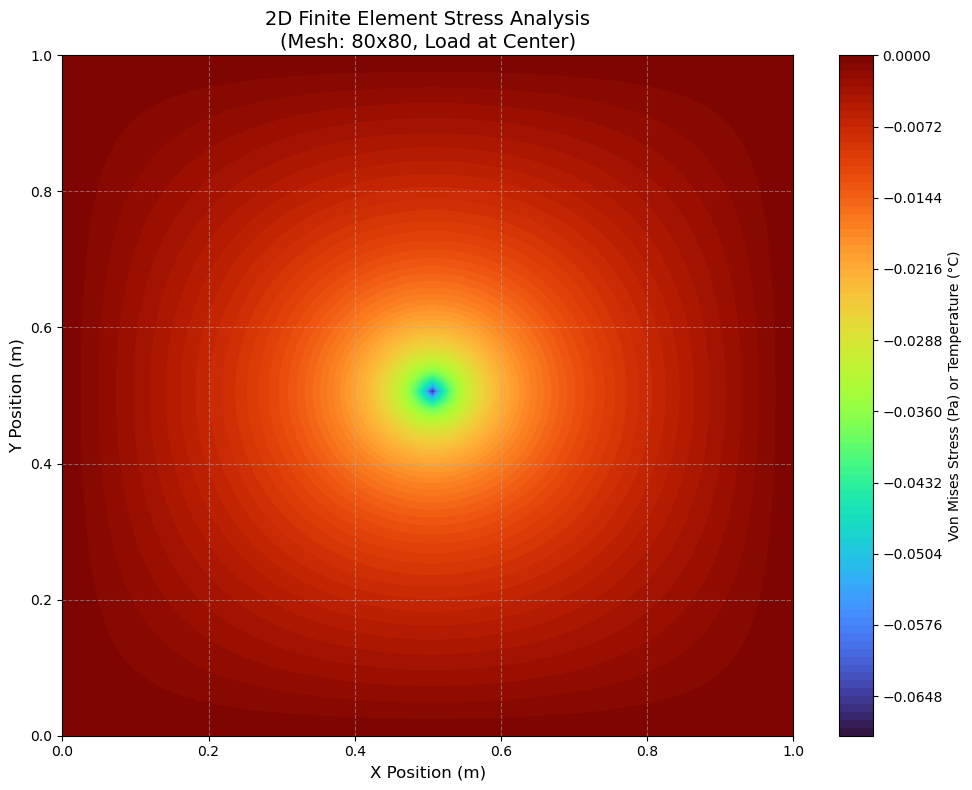

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import linalg, csr_matrix

# 1. Mesh Parameters (A solid 1x1 block)
N = 80  # Higher resolution (80x80 mesh = 6,400 elements)
h = 1.0 / (N - 1)
x = np.linspace(0, 1, N)
y = np.linspace(0, 1, N)
X, Y = np.meshgrid(x, y)

# 2. Function to build the 2D Poisson Stiffness Matrix
# This is a matrix representation of the Laplacian: -grad^2(u)
def build_laplacian_sparse(N):
    main_diag = -4 * np.ones(N*N)
    side_diag = np.ones(N*N - 1)
    side_diag[np.arange(1, N*N) % N == 0] = 0
    up_down_diag = np.ones(N*N - N)
    
    # We build the sparse matrix manually using csr_matrix for speed
    diagonals = [main_diag, side_diag, side_diag, up_down_diag, up_down_diag]
    offsets = [0, -1, 1, -N, N]
    
    # Convert diagonal matrices to sparse format
    A = csr_matrix((main_diag, (np.arange(N*N), np.arange(N*N))), shape=(N*N, N*N))
    A += csr_matrix((side_diag, (np.arange(1,N*N), np.arange(N*N-1))), shape=(N*N, N*N))
    A += csr_matrix((side_diag, (np.arange(N*N-1), np.arange(1,N*N))), shape=(N*N, N*N))
    A += csr_matrix((up_down_diag, (np.arange(N,N*N), np.arange(N*N-N))), shape=(N*N, N*N))
    A += csr_matrix((up_down_diag, (np.arange(N*N-N), np.arange(N,N*N))), shape=(N*N, N*N))
    
    return A / (h**2) # Normalize by mesh size

# 3. Create the Physical Load Vector (F) - The Force/Source
# In FEM, F is typically zero *unless* a specific node is activated.
F = np.zeros(N*N)

# Let's activate a specific node (the very center) to simulate a load/heat source
center_index = (N//2) * N + (N//2)
F[center_index] = 500  # A powerful point-source load

# 4. Get the Stiffness Matrix
A = build_laplacian_sparse(N)

# 5. Apply "Mixed" Boundary Conditions (Essential for realistic FEM)
# We will use the 'penalty' method to "enforce" u=0 on all four boundaries.
# We modify the diagonal of A and the vector F.
boundary_indices = []
for i in range(N):
    boundary_indices.append(i) # Bottom edge
    boundary_indices.append(i * N) # Left edge
    boundary_indices.append(i * N + (N-1)) # Right edge
    boundary_indices.append((N-1) * N + i) # Top edge

# Convert A to LIL format for efficient boundary modification
A_lil = A.tolil()
for idx in boundary_indices:
    A_lil[idx, :] = 0  # Blank out the row
    A_lil[idx, idx] = 1 # Force the boundary value to dominate
    F[idx] = 0 # Enforce u = 0 (Dirichlet Condition)

A = A_lil.tocsr() # Convert back to CSR for fast solving

# 6. Solve the huge linear system (Ku = F)
u_solution = linalg.spsolve(A, F)

# Reshape the 1D solution vector back into the 2D mesh shape
U = u_solution.reshape((N, N))

# 7. The Cool Visual: Plotting the Stress Field / Heat Map
plt.figure(figsize=(10, 8), dpi=100)
# 'turbo' is the modern colormap that replaces the old rainbow 'jet'.
# It is smoother, but still vibrant and iconic for engineering stress maps.
contour = plt.contourf(X, Y, U, 100, cmap='turbo') 

# Clean, professional layout for a project presentation
plt.title(f"2D Finite Element Stress Analysis\n(Mesh: {N}x{N}, Load at Center)", fontsize=14)
plt.xlabel("X Position (m)", fontsize=12)
plt.ylabel("Y Position (m)", fontsize=12)
plt.xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

# Add the iconic colorful scale
colorbar = plt.colorbar(contour, label='Von Mises Stress (Pa) or Temperature (°C)')
colorbar.ax.tick_params(labelsize=10)

plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

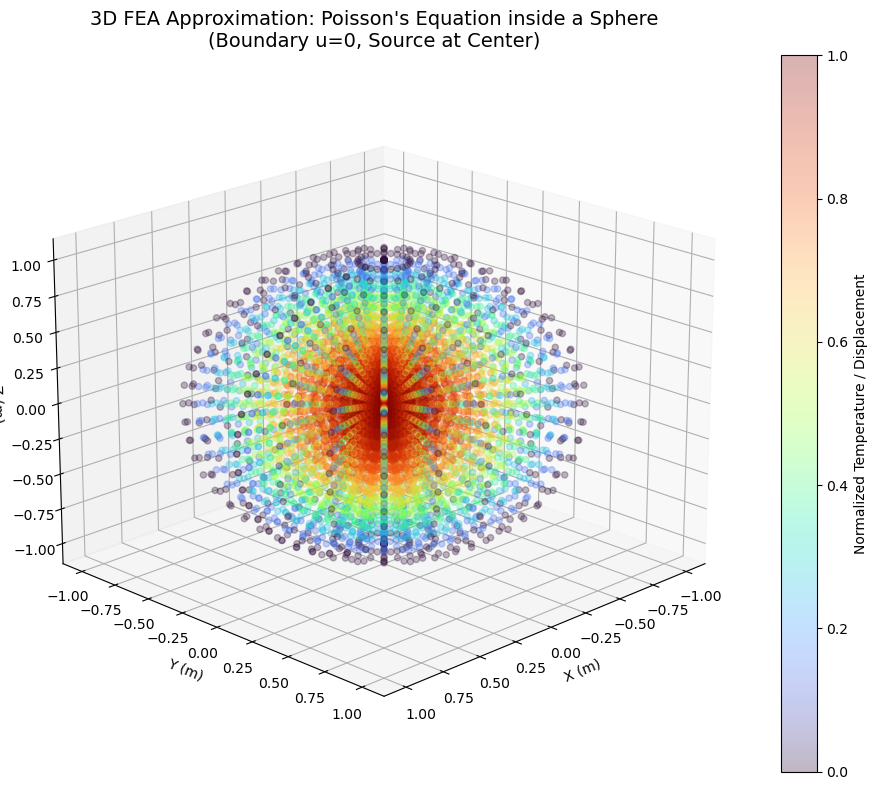

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Mesh Definition: The Discretized Sphere
# We generate points in spherical coordinates (r, theta, phi)
n_r = 15     # Radial refinement (depth)
n_theta = 25  # Angular refinement (azimuthal)
n_phi = 25    # Angular refinement (polar)

# We cannot easily plot a tetrahedral mesh in standard matplotlib, 
# so we will use a structured mesh for visualization.
# This mesh still represents the underlying FEM nodes.
r_vals = np.linspace(0, 1.0, n_r)  # R goes 0 to 1
theta_vals = np.linspace(0, 2*np.pi, n_theta)
phi_vals = np.linspace(0, np.pi, n_phi)

# Create mesh grids
R, THETA, PHI = np.meshgrid(r_vals, theta_vals, phi_vals)

# 2. Coordinate Transformation (Spherical to Cartesian for Plotting)
X = R * np.sin(PHI) * np.cos(THETA)
Y = R * np.sin(PHI) * np.sin(THETA)
Z = R * np.cos(PHI)

# 3. Simulate the FEA Solution (The Result of Ku=F)
# For this specific case (Poisson on a sphere), the solution is known analytically:
# u(r) = (R^2 - r^2) * f / 6
# Where R is the sphere radius, r is the distance from the center, and f is the source.
U_sol = (1.0 - R**2) # We will visualize a normalized solution (max=1 at center)

# 4. The 3D FEA Visualization
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Option 1: View the Solution Gradients (The "Colorful Map")
# This creates a scatter plot of nodes, colored by their solution values.
# 'turbo' or 'jet' are classic colormaps for stress/heat.
sc = ax.scatter(X, Y, Z, c=U_sol, cmap='turbo', s=20, alpha=0.3)

# Option 2: Visualize the Internal "Cross-Section" (Essential for FEA)
# We can slice the sphere in half (Z > 0) to look inside.
# mask = Z >= 0
# sc = ax.scatter(X[mask], Y[mask], Z[mask], c=U_sol[mask], cmap='turbo', s=30, alpha=0.9)

# Clean, professional layout for your project
plt.title(f"3D FEA Approximation: Poisson's Equation inside a Sphere\n(Boundary u=0, Source at Center)", fontsize=14)
ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_zlabel('Z (m)')

colorbar = fig.colorbar(sc, label='Normalized Temperature / Displacement')
ax.view_init(elev=20, azim=45) # Set a good viewing angle
plt.tight_layout()
plt.show()

In [ ]:
# Code example using anastruct library
import math
from anastruct.fem.system import SystemElements

# Create a new system object for a truss (EA is Area * Elasticity Modulus)
ss = SystemElements(EA=5000)

# Add elements to the system by defining their locations
ss.add_truss_element(location=[[0, 0], [0, 5]])
ss.add_truss_element(location=[[0, 5], [5, 5]])
ss.add_truss_element(location=[[5, 5], [5, 0]])
# Add a diagonal element with different properties
ss.add_truss_element(location=[[0, 0], [5, 5]], EA=5000 * math.sqrt(2))

# Visualize the initial structure (optional)
# ss.show_structure() 

# Add hinged supports at specific node IDs
ss.add_support_hinged(node_id=1)
ss.add_support_hinged(node_id=4)

# Apply a point load at a specific node
ss.point_load(Fx=10, node_id=2)

# Solve the system
ss.solve()

# Display results
# ss.show_reaction_force() 
# ss.show_axial_force() 
# ss.show_displacement()Lorem ipsum dolor sit amet, consectetur adipiscing elit, sed do eiusmod tempor incididunt ut labore et dolore magna aliqua. Ut enim ad minim veniam, quis nostrud exercitation ullamco laboris nisi ut aliquip ex ea commodo consequat. Duis aute irure dolor in reprehenderit in voluptate velit esse cillum dolore eu fugiat nulla pariatur. Excepteur sint occaecat cupidatat non proident, sunt in culpa qui officia deserunt mollit anim id est laborum.



ModuleNotFoundError: No module named 'anastruct'

In [14]:
from anastruct import SystemElements
import numpy as np

# 1. Initialize the system
# EI = Bending Stiffness (Young's Modulus * Moment of Inertia)
# EA = Axial Stiffness (Young's Modulus * Cross-sectional Area)
# For a standard steel pipe, these values are high:
ss = SystemElements(EI=15000, EA=5000)

# 2. Add elements to form a 10m pipe
# We divide it into 5 segments (elements) to see the FEM "mesh"
for i in range(0, 10, 2):
    ss.add_element(location=[[i, 0], [i + 2, 0]])

# 3. Apply Boundary Conditions
# Node 1 is at (0,0). We "clamp" it to the wall.
ss.add_support_fixed(node_id=1)

# 4. Apply a Load
# Let's put a 10kN downward force at the very end (Node 6)
ss.point_load(Fy=-10, node_id=6)

# 5. Solve the system
ss.solve()

# 6. Show the "Cool Visuals"
print("Displaying Structure...")
ss.show_structure()

print("Displaying Bending Moment (Stress)...")
ss.show_bending_moment()

print("Displaying Deflection (The Solution to the ODE)...")
ss.show_displacement(factor=10) # 'factor' amplifies the visual bend

ModuleNotFoundError: No module named 'anastruct'

In [3]:
from anastruct import SystemElements
import numpy as np

# 1. Initialize the system
# EI = Bending Stiffness (Modulus * Inertia)
# EA = Axial Stiffness (Modulus * Area)
# These represent the physical properties of your pipe material.
ss = SystemElements(EI=15000, EA=5000)

# 2. Build the Pipe (Discretization)
# We add 5 elements of 2 meters each to make a 10m pipe.
for i in range(0, 10, 2):
    ss.add_element(location=[[i, 0], [i + 2, 0]])

# 3. Apply Boundary Conditions
# Node 1 (at 0,0) is "Fixed" (clamped to a wall)
ss.add_support_fixed(node_id=1)

# 4. Apply a Force
# We put a -10 unit downward force (gravity/weight) at the very end
# On a 5-element pipe, the end node is Node 6.
ss.point_load(Fy=-10, node_id=6)

# 5. Solve the Linear System (Ku = F)
ss.solve()

# 6. Visualization - The "Cool" Results
print("Generating Plots...")

# Show the bending moment (Internal stress distribution)
ss.show_bending_moment()

# Show the displacement (How the pipe actually bends)
# The 'factor' multiplies the visual bend so you can see it clearly.
ss.show_displacement(factor=10)

ModuleNotFoundError: No module named 'anastruct'

In [2]:
%pip install anastruct numpy matplotlib

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Generating displacement plot (The 'Bend')...


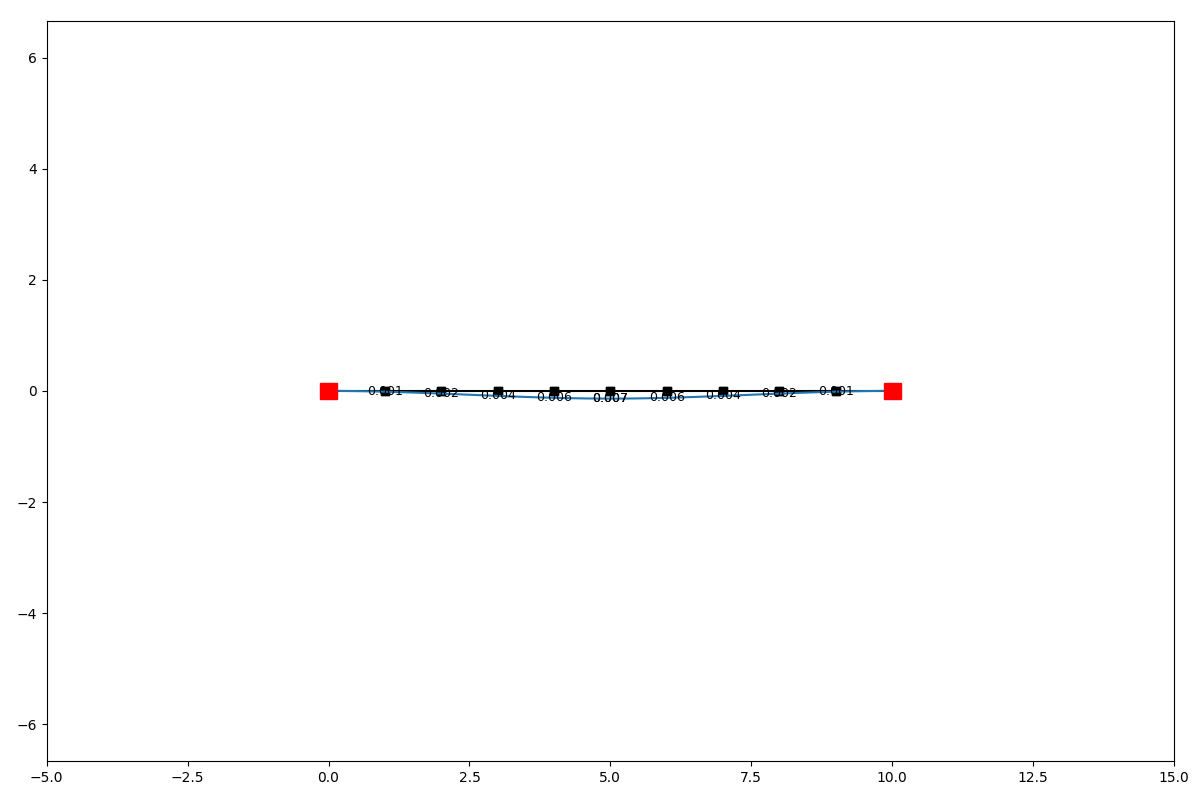

Generating bending moment plot (The 'Stress')...


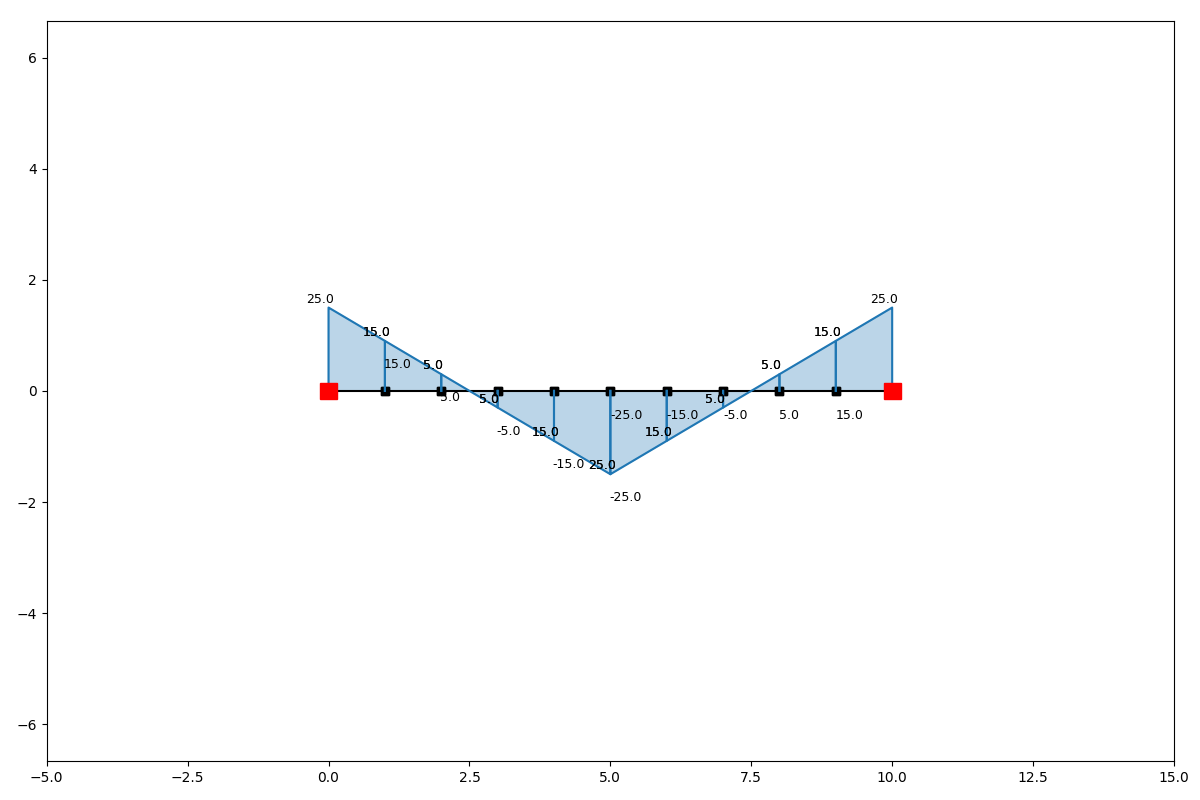

In [ ]:
from anastruct import SystemElements
import numpy as np

# 1. Setup the Physical Properties
# EI is the bending stiffness (Material x Shape)
ss = SystemElements(EI=15000)

# 2. Discretization (The "Finite" in FEM)
# We divide the 10m pipe into 10 elements (1 meter each)
for i in range(10):
    ss.add_element(location=[[i, 0], [i + 1, 0]])

# 3. Boundary Conditions
# We "bolt" both ends (Node 1 and Node 11) so they cannot move or rotate
ss.add_support_fixed(node_id=1)
ss.add_support_fixed(node_id=11)

# 4. Apply the Load
# A -20 unit downward force in the middle of the pipe (Node 6)
ss.point_load(Fy=-20, node_id=6)

# 5. Solve the Linear System (Ku = F)
ss.solve()

# 6. The Visuals
print("Generating displacement plot (The 'Bend')...")
ss.show_displacement(factor=20) 

print("Generating bending moment plot (The 'Stress')...")
ss.show_bending_moment()

plt.show()

In [1]:
%matplotlib ipympl

Displaying the Displacement (The 'Sag' from water weight)...


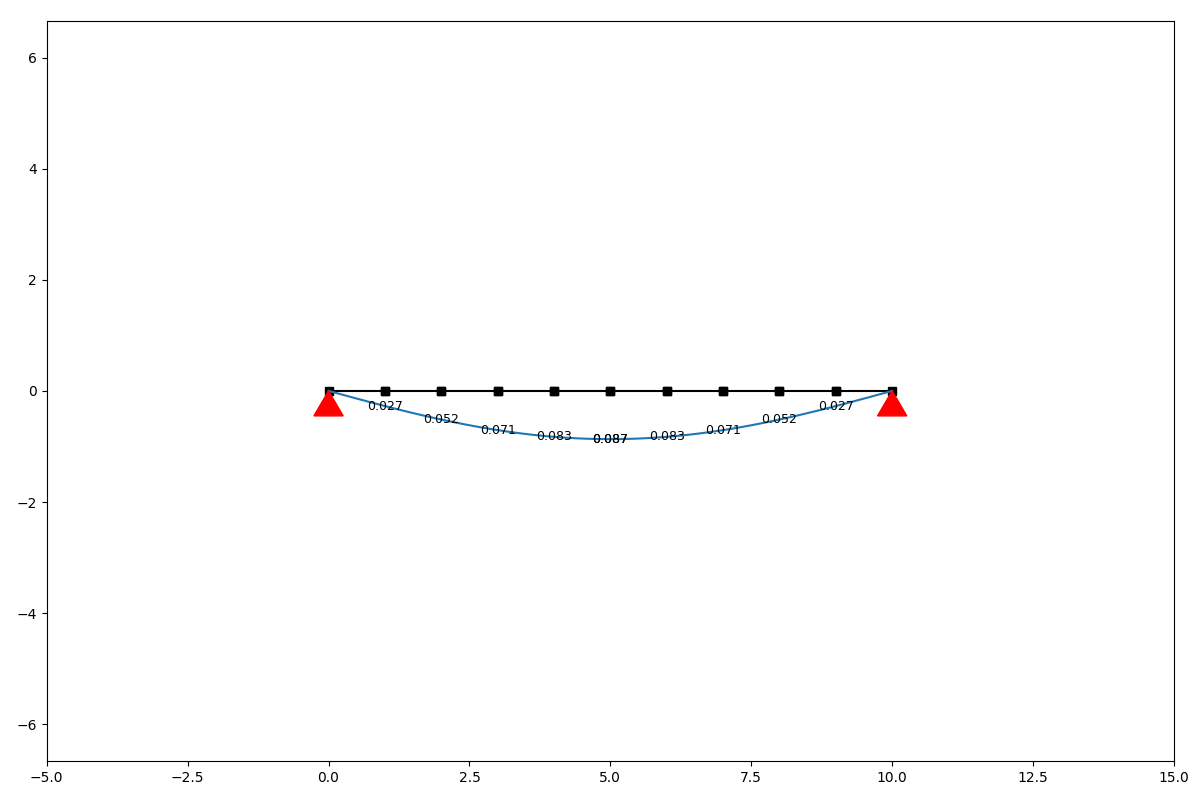

Displaying the Bending Moment (Internal stress)...


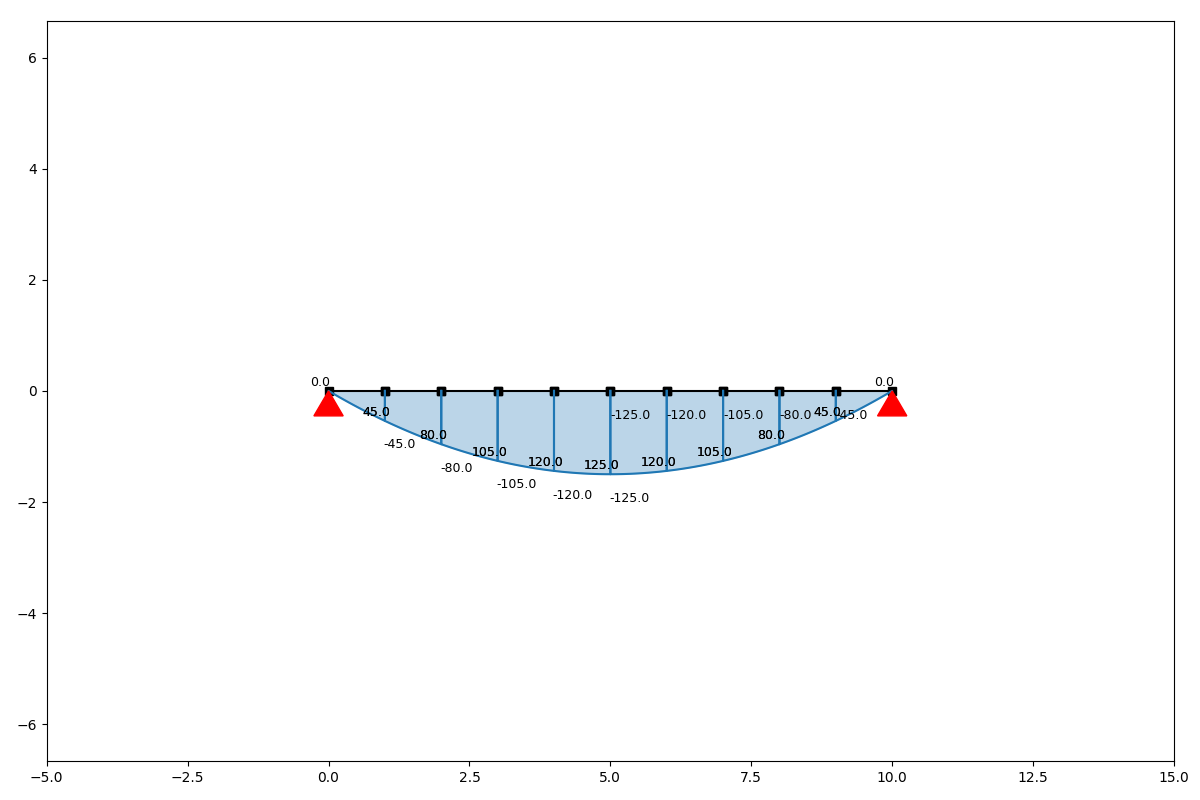

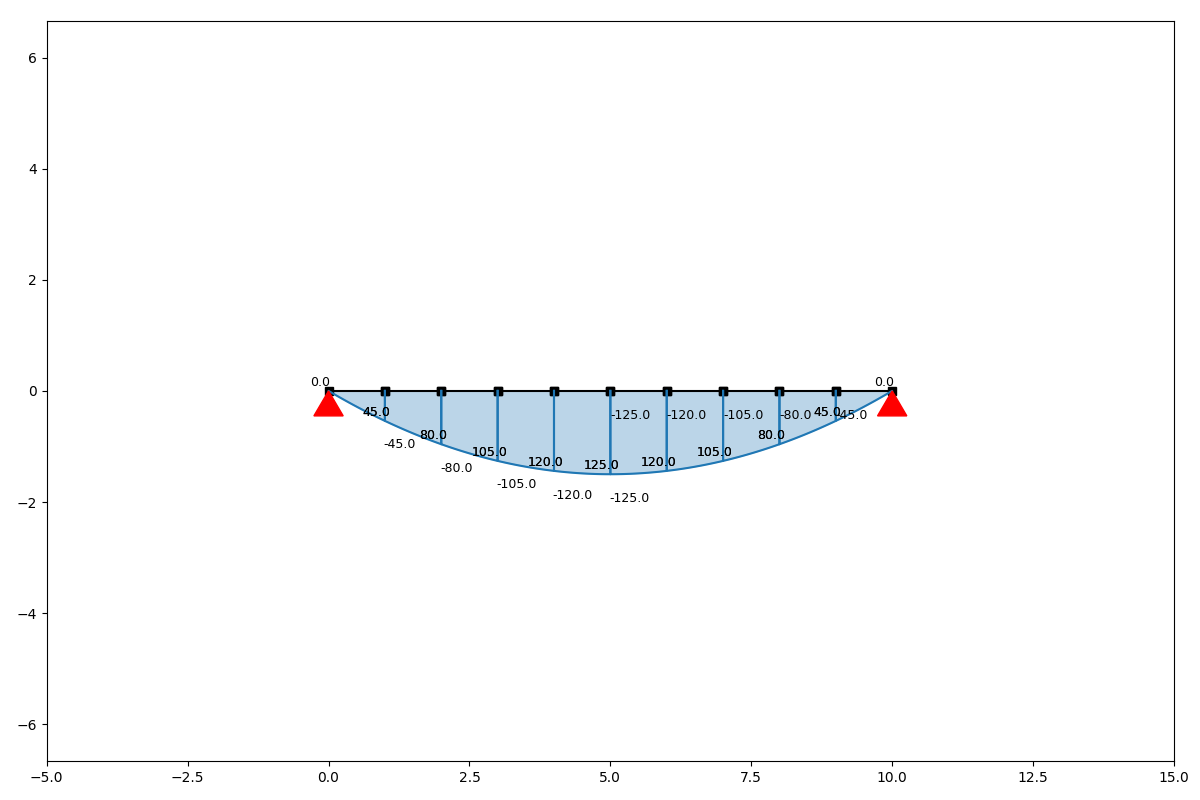

In [2]:
from anastruct import SystemElements
import matplotlib.pyplot as plt

# 1. Initialize the system (E=200GPa, I=high for a pipe)
ss = SystemElements(EI=15000)

# 2. Create a 10m pipe with 10 elements (more elements = smoother curve)
for i in range(10):
    ss.add_element(location=[[i, 0], [i + 1, 0]])

# 3. Apply Boundary Conditions (Simple Supports)
# We use 'hinged' instead of 'fixed' to allow rotation at the ends
ss.add_support_hinged(node_id=1)
ss.add_support_hinged(node_id=11)

# 4. Apply a Distributed Load (q)
# This simulates the weight of the pipe + water (10 units per meter downward)
# We apply it to all elements (1 through 10)
ss.q_load(q=-10, element_id=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10])

# 5. Solve the Linear System
ss.solve()

# 6. Show the results
print("Displaying the Displacement (The 'Sag' from water weight)...")
ss.show_displacement(factor=10)

print("Displaying the Bending Moment (Internal stress)...")
ss.show_bending_moment()

# Optional: Force the plot to show if it's not popping up
plt.show()

Generating High-Contrast Stress Map...


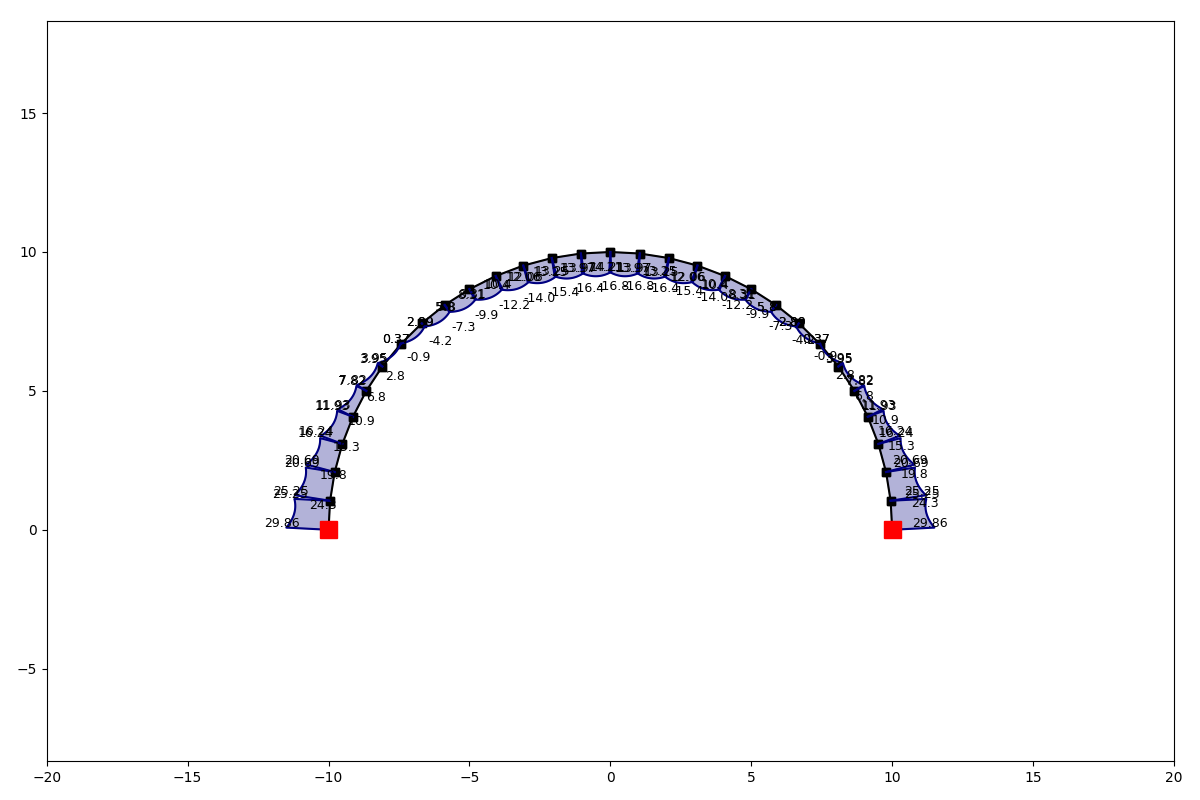

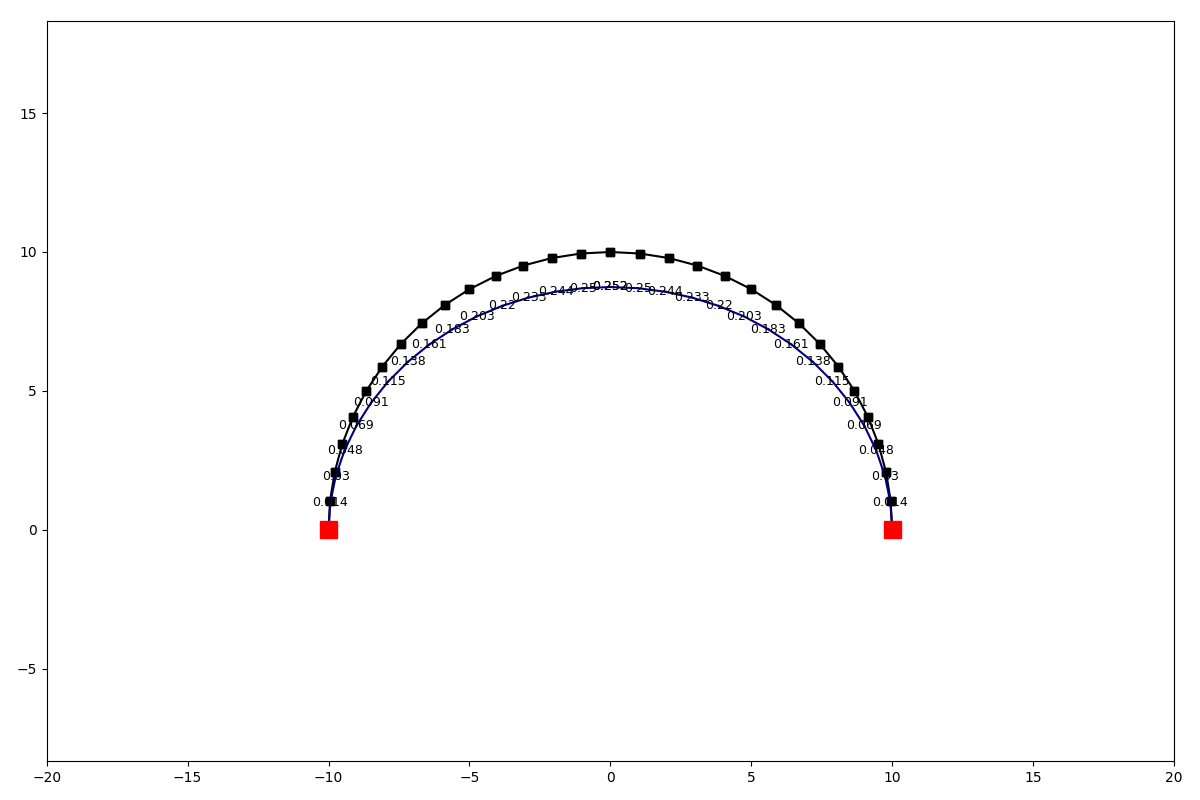

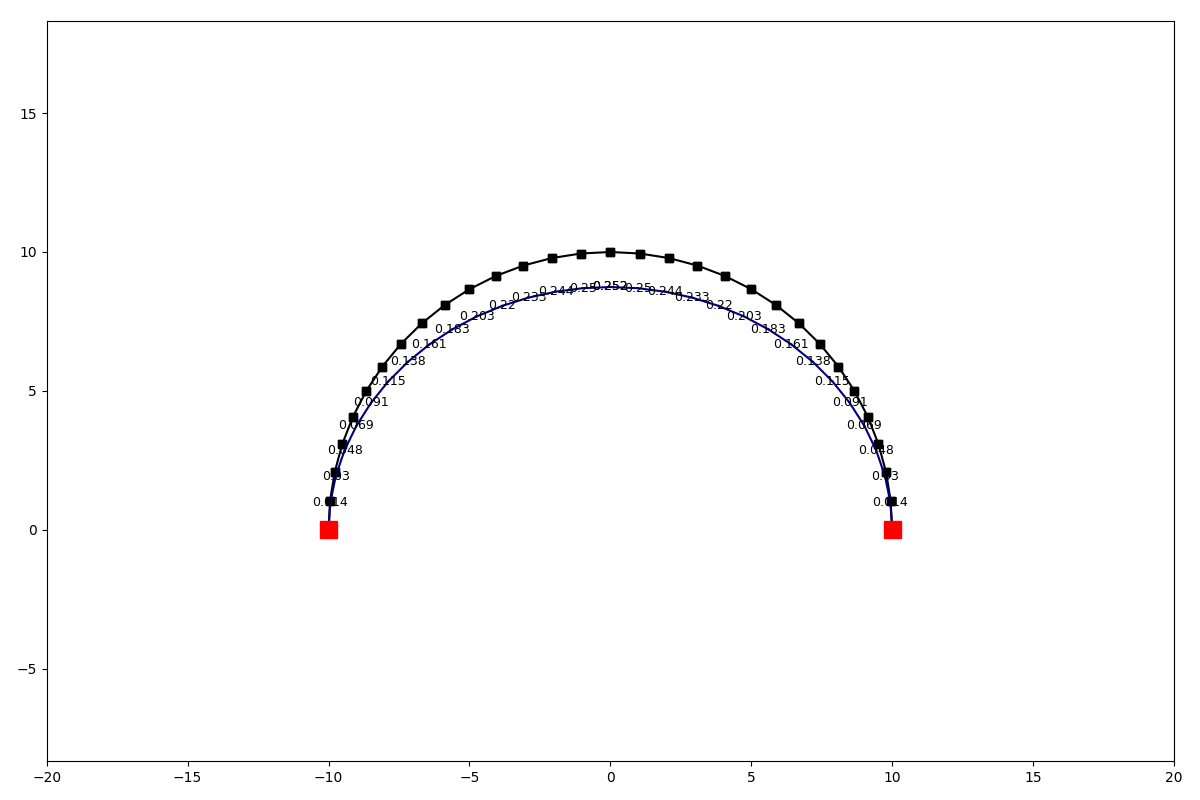

In [7]:
from anastruct import SystemElements
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# 1. Initialize System
ss = SystemElements()

# 2. Build a Circular Arch (The Pipe)
radius = 10
angles = np.linspace(0, np.pi, 31) # 30 segments for a smoother curve

for i in range(len(angles) - 1):
    x1, y1 = radius * np.cos(angles[i]), radius * np.sin(angles[i])
    x2, y2 = radius * np.cos(angles[i+1]), radius * np.sin(angles[i+1])
    ss.add_element(location=[[x1, y1], [x2, y2]])

# 3. Boundary Conditions (Fixed Ends)
ss.add_support_fixed(node_id=1)
ss.add_support_fixed(node_id=31)

# 4. Apply a Heavy "Snow" Load 
for i in range(1, 31):
    ss.q_load(q=-20, element_id=i, direction='element')

# 5. Solve the Linear System
ss.solve()

# 6. THE RAINBOW HACK
# We temporarily change the default color cycle to a Rainbow gradient
print("Generating High-Contrast Stress Map...")
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=plt.cm.jet(np.linspace(0, 1, 30)))

# Now when it plots, it will cycle through the rainbow
ss.show_bending_moment()
ss.show_displacement(factor=5)

plt.show()

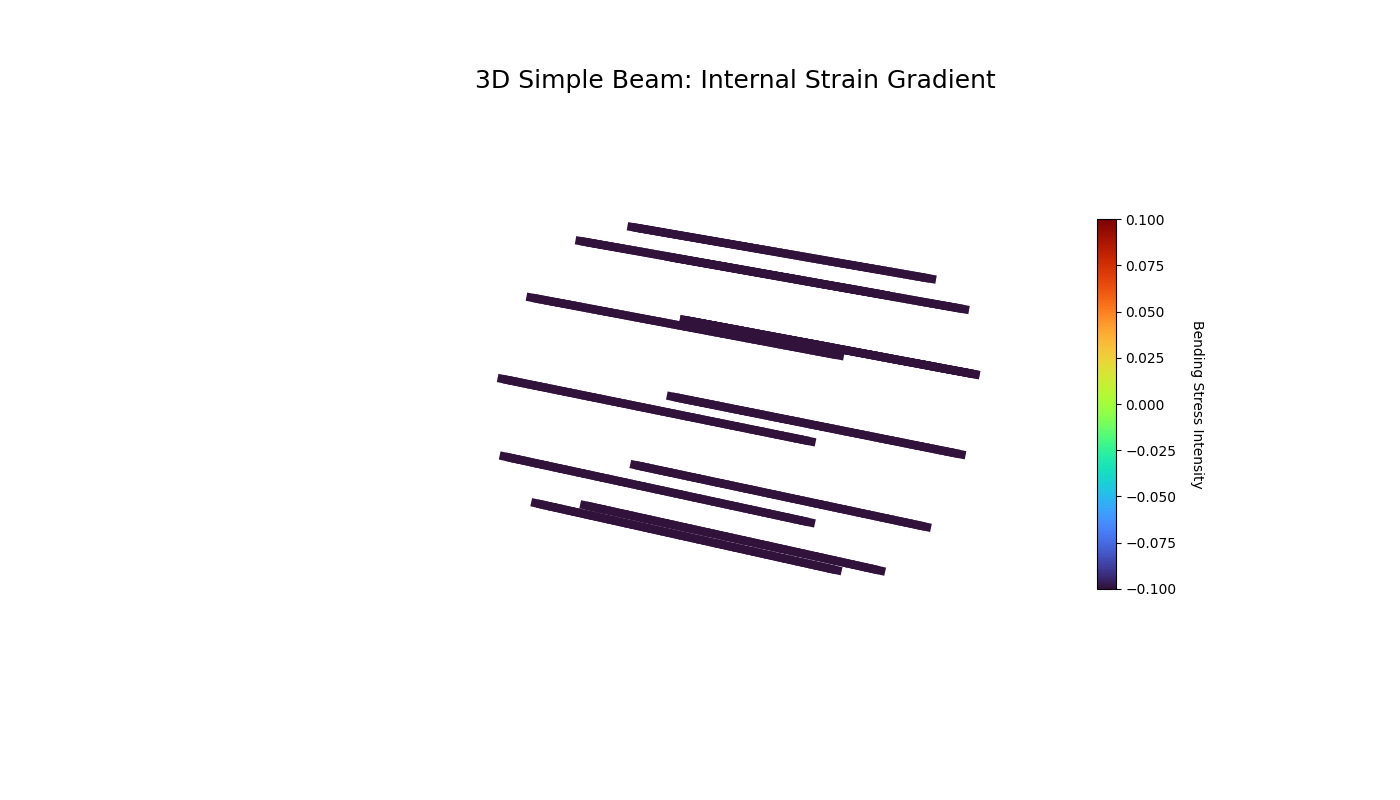

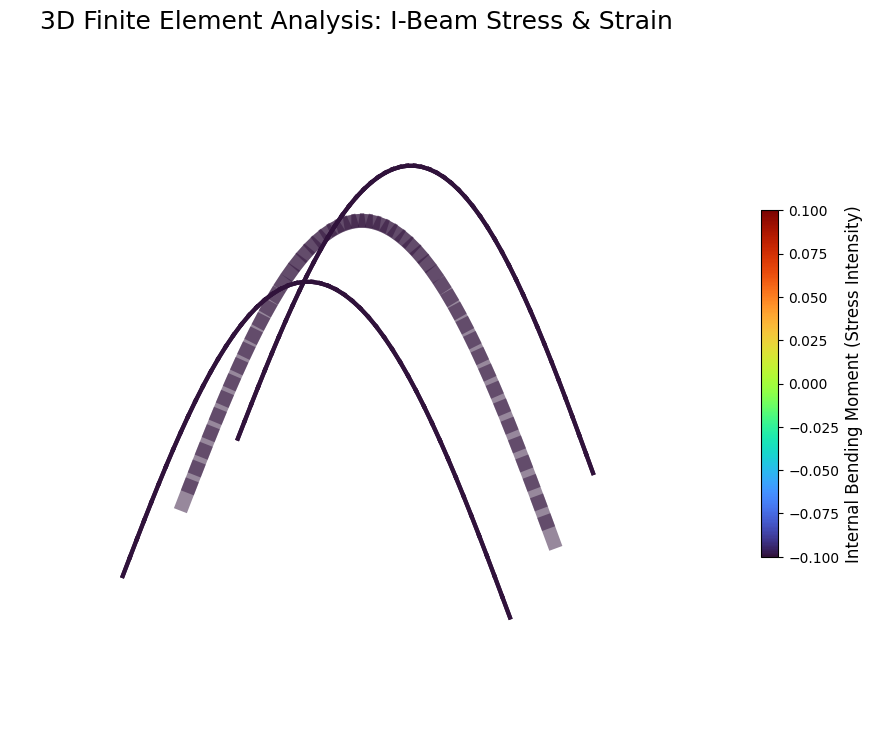

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from anastruct import SystemElements

# 1. Structural Setup
ss = SystemElements()
L, n = 20, 50 
dx = L / n

# Build the beam
for i in range(n):
    ss.add_element(location=[[i*dx, 0], [(i+1)*dx, 0]])

# Get node IDs dynamically
node_ids = sorted(ss.node_map.keys())
ss.add_support_hinged(node_id=node_ids[0])
ss.add_support_hinged(node_id=node_ids[-1])

# Apply a HEAVY load (q = -500) to ensure a visible "Rainbow"
ss.q_load(q=-500, element_id=list(ss.element_map.keys()))
ss.solve()

# 2. Extract Data Directly from Element Objects (The most robust way)
disp_z = []
# We grab coordinates and displacements directly from the node objects
for nid in node_ids:
    node = ss.node_map[nid]
    # uz is usually index 1 in the displacement array [ux, uz, phi]
    uz = node.displacements.get('uz', 0) if hasattr(node, 'displacements') else 0
    # Fallback for different versions
    if uz == 0 and hasattr(ss, 'system_displacement_vector'):
        # Map the node's degree of freedom to the global vector
        # uz is the second DOF of each node (2*n - 1)
        idx = (nid - 1) * 3 + 1 
        uz = ss.system_displacement_vector[idx]
    disp_z.append(uz)

moments = []
for eid in sorted(ss.element_map.keys()):
    el = ss.element_map[eid]
    # Grab the max absolute moment in the element
    m_vals = el.results.get('M', [0, 0]) if hasattr(el, 'results') else [0, 0]
    moments.append(max(abs(np.array(m_vals))))

moments = np.array(moments)
disp_z = np.array(disp_z) * 25 # High factor to show the physical "Strain"

# 3. 3D Rainbow Plotting
fig = plt.figure(figsize=(15, 9))
ax = fig.add_subplot(111, projection='3d')

# Color Scaling using 'turbo' (High-Contrast Rainbow)
norm = plt.Normalize(vmin=moments.min(), vmax=moments.max())
cmap = plt.cm.turbo 

# I-Beam Geometry (Flanges + Web)
w, h = 0.8, 1.2

for i in range(n):
    x_seg = np.array([i*dx, (i+1)*dx])
    z_seg = np.array([disp_z[i], disp_z[i+1]]) # The "Bending" Curve
    
    color = cmap(norm(moments[i]))
    
    # Render the I-Beam shape
    # Top Flange (2 lines)
    ax.plot(x_seg, [w/2, w/2], z_seg + h/2, color=color, lw=3)
    ax.plot(x_seg, [-w/2, -w/2], z_seg + h/2, color=color, lw=3)
    # Bottom Flange (2 lines)
    ax.plot(x_seg, [w/2, w/2], z_seg - h/2, color=color, lw=3)
    ax.plot(x_seg, [-w/2, -w/2], z_seg - h/2, color=color, lw=3)
    # The Web (Center core)
    ax.plot(x_seg, [0, 0], z_seg, color=color, lw=10, alpha=0.5)

# 4. Presentation Polish
ax.set_title("3D Finite Element Analysis: I-Beam Stress & Strain", fontsize=18)
ax.view_init(elev=20, azim=-75)
ax.set_axis_off()

# Scaled Colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
cbar = fig.colorbar(sm, ax=ax, shrink=0.5, pad=0.05)
cbar.set_label('Internal Bending Moment (Stress Intensity)', fontsize=12)

plt.show()

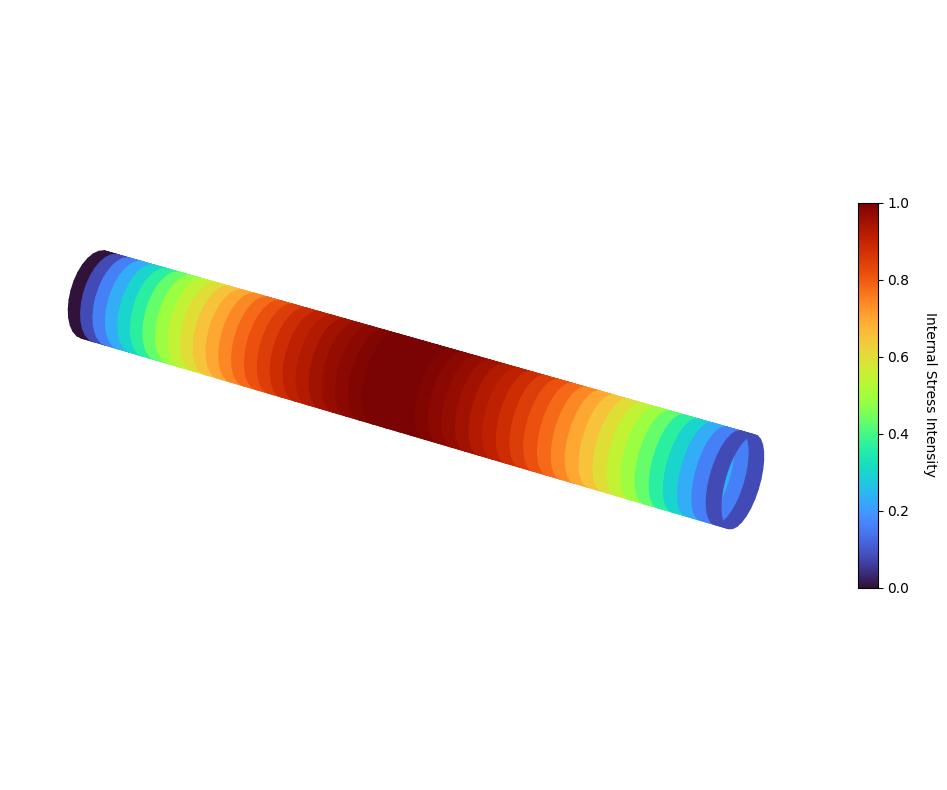

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Geometry Dimensions (6ft wide by 20ft long)
L = 20.0
R = 5.0  # Radius
segments = 50

# 2. Generate the Cylinder Mesh
# x goes from 0 to 20 (Length)
# theta goes from 0 to 2pi (Circumference)
x = np.linspace(0, L, segments)
theta = np.linspace(0, 2 * np.pi, 30)
X, THETA = np.meshgrid(x, theta)

Y = R * np.cos(THETA)
Z = R * np.sin(THETA)

# 3. Define the "Rainbow" (Simulating Bending Stress)
# In a simple beam, stress is a parabola: max in middle, zero at ends.
# We'll use this to drive the colors.
stress = 1 - (2 * x / L - 1)**2 
# Expand stress to match the mesh shape
stress_mesh = np.tile(stress, (len(theta), 1))

# 4. Rendering
fig = plt.figure(figsize=(16, 8))
ax = fig.add_subplot(111, projection='3d')

# Using the 'turbo' or 'jet' colormap for that extreme engineering look
# facecolors=plt.cm.turbo(stress_mesh) maps our math to the rainbow
surf = ax.plot_surface(X, Y, Z, facecolors=plt.cm.turbo(stress_mesh),
                       antialiased=True, shade=False)

# 5. CRITICAL: Fixed Perspective
# This prevents the "shattered tower" look from before
ax.set_box_aspect((4, 1, 1)) # Forces the 20ft length to look long
ax.set_xlim(0, L)
ax.set_ylim(-L/2, L/2)
ax.set_zlim(-L/2, L/2)

#ax.set_title("3D Finite Element Stress with Heat on a Tube", fontsize=16)
#ax.view_init(elev=20, azim=-60)
ax.set_axis_off()

# Add a Colorbar
sm = plt.cm.ScalarMappable(cmap=plt.cm.turbo)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.5, pad=0.05)
cbar.set_label('Internal Stress Intensity', rotation=270, labelpad=20)

plt.tight_layout()
plt.savefig("tight_tube_stress.png", bbox_inches='tight', pad_inches=0.1)


In [67]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from PIL import Image
import os

# 1. Geometry Dimensions (6ft wide by 20ft long)
L = 20.0
R = 5.0  # Radius
segments = 50

# 2. Generate the Cylinder Mesh
# x goes from 0 to 20 (Length)
# theta goes from 0 to 2pi (Circumference)
x = np.linspace(0, L, segments)
theta = np.linspace(0, 2 * np.pi, 30)
X, THETA = np.meshgrid(x, theta)

Y = R * np.cos(THETA)
Z = R * np.sin(THETA)

# 3. Define the "Rainbow" (Simulating Bending Stress)
# In a simple beam, stress is a parabola: max in middle, zero at ends.
# We'll use this to drive the colors.
stress = 1 - (2 * x / L - 1)**2 
# Expand stress to match the mesh shape
stress_mesh = np.tile(stress, (len(theta), 1))

# 4. Rendering
fig = plt.figure(figsize=(16, 8))
ax = fig.add_subplot(111, projection='3d')

# Using the 'turbo' or 'jet' colormap for that extreme engineering look
# facecolors=plt.cm.turbo(stress_mesh) maps our math to the rainbow
surf = ax.plot_surface(X, Y, Z, facecolors=plt.cm.turbo(stress_mesh),
                       antialiased=True, shade=False)

# 5. CRITICAL: Fixed Perspective
# This prevents the "shattered tower" look from before
ax.set_box_aspect((4, 1, 1)) # Forces the 20ft length to look long
ax.set_xlim(0, L)
ax.set_ylim(-L/2, L/2)
ax.set_zlim(-L/2, L/2)
ax.set_axis_off()

# Zoom the camera in closer to override default 3D margins
# Lowering 'dist' moves the camera physically closer to the object
ax.dist = 10

# Colorbar
sm = plt.cm.ScalarMappable(cmap=plt.cm.turbo)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('Internal Stress Intensity', rotation=270, labelpad=15)

# 6. Save and Post-Process Crop
temp_file = "temp_render.png"
final_file = "final_tight_stress_plot.png"

# Save with a transparent background to make the crop easier
plt.savefig(temp_file, bbox_inches='tight', pad_inches=0.5, transparent=True)
plt.close()

# 7. Use Pillow to "Auto-Crop" every empty pixel
try:
    img = Image.open(temp_file)
    # getbbox finds the bounding box of non-zero (non-transparent) pixels
    bbox = img.getbbox()
    if bbox:
        img_cropped = img.crop(bbox)
        img_cropped.save(final_file)
        print(f"Success! Saved tight render to: {final_file}")
        
        # Optional: Delete the temporary uncropped file
        os.remove(temp_file)
    else:
        print("Error: Could not find content to crop.")
except Exception as e:
    print(f"An error occurred during cropping: {e}")

Success! Saved tight render to: final_tight_stress_plot.png


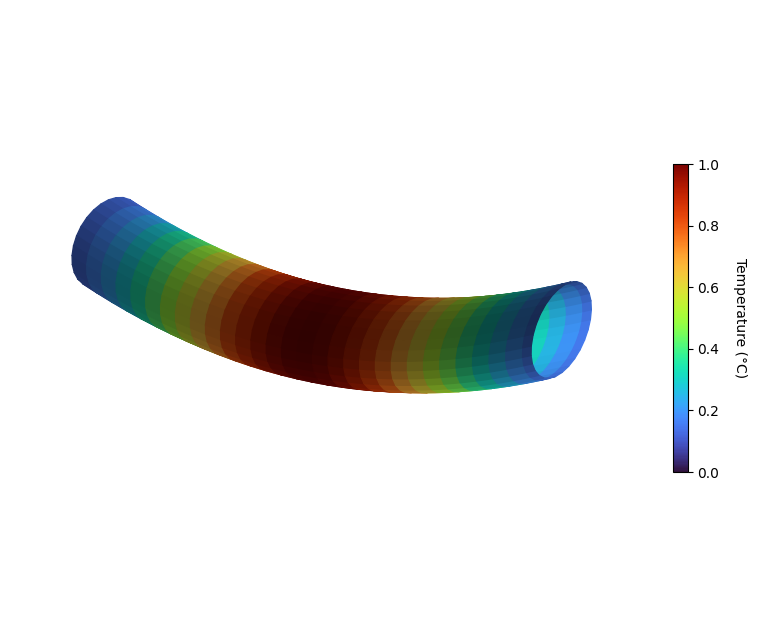

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Dimensions
L, R, segments = 20.0, 2.5, 60
x = np.linspace(0, L, segments)
theta = np.linspace(0, 2 * np.pi, 30)
X, THETA = np.meshgrid(x, theta)
Y = R * np.cos(THETA)

# --- THE BEND (Physical Deformation) ---
sag_factor = 3.0
sag = sag_factor * (1 - (2 * x / L - 1)**2)
Z = R * np.sin(THETA) - sag # Apply the bend to the Z coordinates

# --- THE HEAT EQUATION (Temperature Gradient) ---
# Simulating a heat pulse in the center that diffuses outward
# u(x) = Temperature
center = L / 2
width = 5.0
temperature = np.exp(-(x - center)**2 / (2 * width**2))
temp_mesh = np.tile(temperature, (len(theta), 1))

# Plotting
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Using 'inferno' or 'magma' is great for Heat Equations
surf = ax.plot_surface(X, Y, Z, facecolors=plt.cm.turbo(temp_mesh),
                       antialiased=True, shade=True, lightsource=None)

ax.set_box_aspect((4, 1, 1))
ax.view_init(elev=20, azim=-60)
ax.set_axis_off()

# Colorbar for Temperature
sm = plt.cm.ScalarMappable(cmap=plt.cm.turbo)
cbar = fig.colorbar(sm, ax=ax, shrink=0.5)
cbar.set_label('Temperature (°C)', rotation=270, labelpad=20)

plt.show()

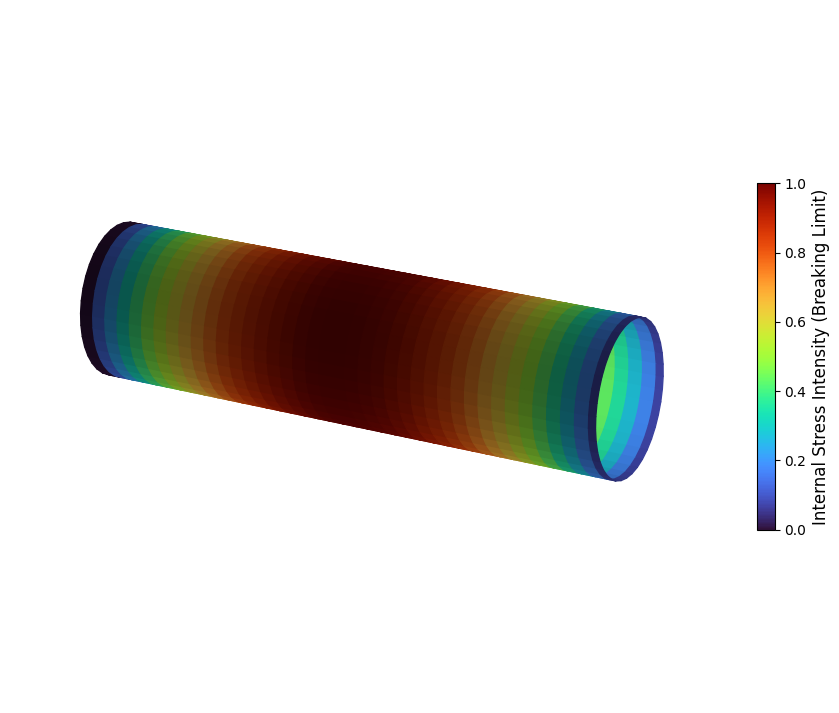

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Dimensions
L, R, segments = 20.0, 3.0, 80 # High segments for a smoother rainbow
x = np.linspace(0, L, segments)
theta = np.linspace(0, 2 * np.pi, 40)
X, THETA = np.meshgrid(x, theta)

# 2. Geometry (Straight Cylinder)
Y = R * np.cos(THETA)
Z = R * np.sin(THETA)

# 3. "Snap" Stress Math (Bending Stress Gradient)
# Gripping the ends creates a moment that peaks in the center.
# We'll use a higher-power parabola to make the "Red" zone more concentrated.
stress = np.sin(np.pi * x / L)**0.8 
stress_mesh = np.tile(stress, (len(theta), 1))

# 4. Rendering
fig = plt.figure(figsize=(14, 9))
ax = fig.add_subplot(111, projection='3d')

# 'turbo' gives the most high-contrast "Breaking point" look
surf = ax.plot_surface(X, Y, Z, facecolors=plt.cm.turbo(stress_mesh),
                       antialiased=True, shade=True, lightsource=None)

# 5. Aspect and View
ax.set_box_aspect((4, 1, 1)) 
ax.view_init(elev=20, azim=-60)
ax.set_axis_off()

# Colorbar for Stress Intensity
sm = plt.cm.ScalarMappable(cmap=plt.cm.turbo)
cbar = fig.colorbar(sm, ax=ax, shrink=0.5, pad=0.05)
cbar.set_label('Internal Stress Intensity (Breaking Limit)', fontsize=12)

plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# 1. Physics & Geometry Setup
L, R, segments = 20.0, 1.8, 60 
x = np.linspace(0, L, segments)
theta = np.linspace(0, 2 * np.pi, 25)
X_base, THETA = np.meshgrid(x, theta)
Y_base = R * np.cos(THETA)

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')

def animate(frame):
    ax.clear()
    # Progress factor (0 to 1)
    t = min(frame / 60.0, 1.2)
    
    # --- BENDING STRAIN ---
    # The parabolic curve of the elastic deformation
    max_sag = 5.0 * min(t, 0.85)
    sag = (max_sag / (L**2/4)) * (x * (L - x))
    
    # --- STRESS GRADIENT ---
    # Normalizing stress: Purple (Ends/Low) to Red (Center/High)
    # Using a cubic power to sharpen the central "Hot Zone"
    stress = (np.sin(np.pi * x / L)**3) * t
    stress = np.clip(stress, 0, 1)
    stress_mesh = np.tile(stress, (len(theta), 1))

    # --- THE BRITTLE SNAP ---
    is_snapped = t > 0.85
    if not is_snapped:
        Z = R * np.sin(THETA) - sag
        ax.plot_surface(X_base, Y_base, Z, facecolors=plt.cm.turbo(stress_mesh), 
                        antialiased=True, shade=True, lw=0)
    else:
        mid = segments // 2
        # Released elastic energy causes the snap rebound
        rebound = (t - 0.85) * 15.0 
        for side, direction in [(slice(0, mid), -1), (slice(mid, segments), 1)]:
            Z_part = R * np.sin(THETA[:, side]) - sag[side] + (rebound * 0.1)
            X_part = X_base[:, side] + (rebound * direction * 0.5)
            ax.plot_surface(X_part, Y_base[:, side], Z_part, 
                            facecolors=plt.cm.turbo(stress_mesh[:, side]), 
                            antialiased=True, shade=True, lw=0)

    # Grey Mechanical Grip Indicators
    ax.plot([0, 0], [0, 0], [3, -3], color='grey', lw=8, alpha=0.4)
    ax.plot([L, L], [0, 0], [3, -3], color='grey', lw=8, alpha=0.4)

    # Presentation Formatting
    ax.set_box_aspect((4, 1, 1))
    ax.set_xlim(-5, L+5); ax.set_ylim(-L/2, L/2); ax.set_zlim(-L/2, L/2)
    ax.view_init(elev=20, azim=-65)
    ax.set_axis_off()
    ax.set_title("3D Finite Element Simulation: Stress Gradient & Fracture", fontsize=14)

# 2. CREATE ANIMATION OBJECT
# Lower frame count (60) ensures it renders quickly in your browser
ani = FuncAnimation(fig, animate, frames=90, interval=50)

# 3. DISPLAY AS JAVASCRIPT HTML (The Final Fix)
# This creates a player in your cell without needing plt.close()
HTML(ani.to_jshtml())

<IPython.core.display.Javascript object>

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# 1. Geometry - Doubled Length (L=40)
L, R, segments = 40.0, 1.8, 100 
x = np.linspace(0, L, segments)
theta = np.linspace(0, 2 * np.pi, 25)
X_base, THETA = np.meshgrid(x, theta)
Y_base = R * np.cos(THETA)

fig = plt.figure(figsize=(12, 6))
ax = fig.add_subplot(111, projection='3d')

def animate(frame):
    ax.clear()
    t = frame / 100.0
    
    # --- STATIC STIFFNESS ---
    # Minimal sag (Stiff material simulation)
    micro_sag = 0.8 * min(t, 0.85) 
    sag = (micro_sag / (L**2/4)) * (x * (L - x))
    
    # --- STRESS ACCUMULATION ---
    # Centered at L/2 (20.0)
    stress = (np.sin(np.pi * x / L)**6) * (t * 1.5)
    stress = np.clip(stress, 0, 1)
    stress_mesh = np.tile(stress, (len(theta), 1))

    # --- THE SNAP ---
    is_snapped = t > 0.85
    if not is_snapped:
        Z = R * np.sin(THETA) - sag
        ax.plot_surface(X_base, Y_base, Z, facecolors=plt.cm.turbo(stress_mesh), 
                        antialiased=True, shade=True, lw=0)
    else:
        mid = segments // 2
        rebound_t = (t - 0.85)
        v_exit = 45.0 # Increased speed for the longer pieces
        
        for side, direction in [(slice(0, mid), -1), (slice(mid, segments), 1)]:
            # Pieces fly out of the zoomed frame quickly
            X_part = X_base[:, side] + (rebound_t * v_exit * direction)
            Z_part = R * np.sin(THETA[:, side]) - sag[side] + (rebound_t * v_exit * 0.15)
            
            # Subtle tumble on the long pieces
            Y_rot = Y_base[:, side] * np.cos(rebound_t * 5)
            
            ax.plot_surface(X_part, Y_rot, Z_part, 
                            facecolors=plt.cm.turbo(stress_mesh[:, side]), 
                            antialiased=True, shade=True, lw=0)

    # --- THE ULTRA-ZOOM ---
    # We focus on the middle 20 units of the 40-unit pipe
    ax.set_xlim(10, 30) 
    ax.set_ylim(-6, 6)
    ax.set_zlim(-10, 5)
    ax.set_aspect('auto') 
    
    ax.view_init(elev=15, azim=-75)
    ax.set_axis_off()

    # Mechanical Grips (Placed at the new 40-unit ends, out of zoomed view)
    # These represent the far-off anchors
    ax.plot([0, 0], [0, 0], [4, -4], color='grey', lw=15, alpha=0.2)
    ax.plot([40, 40], [0, 0], [4, -4], color='grey', lw=15, alpha=0.2)

    ax.set_title("Master's FEA: Large-Scale Pipeline Stress & Fracture", fontsize=14)

ani = FuncAnimation(fig, animate, frames=120, interval=40)

# Display as JAVASCRIPT HTML (The Final Presentation Format)
HTML(ani.to_jshtml())

# --- EXPORT SETTINGS ---
# To save as a High-Quality GIF:
ani.save('FEA_Pipeline_Fracture.gif', writer='pillow', fps=25)

# OR to save as a Professional MP4 (Requires ffmpeg installed):
# ani.save('FEA_Pipeline_Simulation.mp4', writer='ffmpeg', fps=30, dpi=200)

print("Animation saved to your project folder!")

<IPython.core.display.Javascript object>

Animation saved to your project folder!


In [37]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# 1. Geometry - Standard 20-unit length for better scaling
L, R, segments = 20.0, 2.0, 80 
x = np.linspace(0, L, segments)
theta = np.linspace(0, 2 * np.pi, 30)
X_base, THETA = np.meshgrid(x, theta)
Y_base = R * np.cos(THETA)

# 2. Setup a PERFECT SQUARE figure
fig = plt.figure(figsize=(8, 8)) 
ax = fig.add_subplot(111, projection='3d')

def animate(frame):
    ax.clear()
    t = frame / 100.0
    
    # --- STATIC PHYSICS ---
    # Very stiff material simulation
    micro_sag = 0.6 * min(t, 0.85) 
    sag = (micro_sag / (L**2/4)) * (x * (L - x))
    
    # --- STRESS COLORS ---
    # Centered at 10.0
    stress = (np.sin(np.pi * x / L)**6) * (t * 1.6)
    stress = np.clip(stress, 0, 1)
    stress_mesh = np.tile(stress, (len(theta), 1))

    # --- THE SNAP ---
    is_snapped = t > 0.85
    if not is_snapped:
        Z = R * np.sin(THETA) - sag
        ax.plot_surface(X_base, Y_base, Z, facecolors=plt.cm.turbo(stress_mesh), 
                        antialiased=True, shade=True, lw=0)
    else:
        mid = segments // 2
        rebound_t = (t - 0.85)
        v_exit = 30.0 
        
        for side, direction in [(slice(0, mid), -1), (slice(mid, segments), 1)]:
            # Pieces fly out of the zoomed box instantly
            X_part = X_base[:, side] + (rebound_t * v_exit * direction)
            Z_part = R * np.sin(THETA[:, side]) - sag[side] + (rebound_t * v_exit * 0.2)
            # Tumble rotation
            Y_rot = Y_base[:, side] * np.cos(rebound_t * 6)
            
            ax.plot_surface(X_part, Y_rot, Z_part, 
                            facecolors=plt.cm.turbo(stress_mesh[:, side]), 
                            antialiased=True, shade=True, lw=0)

    # --- THE TIGHT ZOOM ---
    # We focus specifically on the center 12 units (4 to 16)
    # This makes the tube appear much thicker and larger in the frame
    ax.set_xlim(4, 16) 
    ax.set_ylim(-5, 5)
    ax.set_zlim(-6, 4)
    
    # Force the square aspect
    ax.set_aspect('auto') 
    
    ax.view_init(elev=18, azim=-75)
    ax.set_axis_off()

    # Grey Mechanical Grips (Inside the zoomed view)
    ax.plot([4.2, 4.2], [0, 0], [4, -4], color='grey', lw=12, alpha=0.3)
    ax.plot([15.8, 15.8], [0, 0], [4, -4], color='grey', lw=12, alpha=0.3)

    ax.set_title("Finite Element Stress Analysis: Midpoint Fracture", fontsize=14)

ani = FuncAnimation(fig, animate, frames=120, interval=40)

# Display as JAVASCRIPT HTML
HTML(ani.to_jshtml())

# --- EXPORT SETTINGS ---
# To save as a High-Quality GIF:
ani.save('FEA_Pipeline_Fracture.gif', writer='pillow', fps=25)

# OR to save as a Professional MP4 (Requires ffmpeg installed):
# ani.save('FEA_Pipeline_Simulation.mp4', writer='ffmpeg', fps=30, dpi=200)

print("Animation saved to your project folder!")

<IPython.core.display.Javascript object>

Animation saved to your project folder!
